# Machine Learning Project - A ML Classification Example

<h1>Machine Learning Pipeline<h1>

<h5> 1. Define the application </h5>
<h5> 2. Load data (smiles + target values)</h5>
<h5> 3. Explore, standardize and clean data  </h5>
<h5> 4. Featurize molecules (descriptors / fingerprints) </h5>
<h5> 5. Split data (training and test set) </h5>
<h5> 6. Choose and build ML model (classification / regression) </h5>
<h5> 7. Train model on training set </h5>
<h5> 8. Evaluate model on test set </h5>
<h5> 9. Improve model (optimization, hyperparamater tuning, etc) </h5>
<h5> 10. Save, Load, Use model for predictions on new data </h5>
<h5> 11. Optional: Deploy model </h5>

<h5>

>**Machine Learning Pipeline:  
Data → Features → Model → Train → Evaluation → Optimization → Prediction**  

</h5>

In [1]:
# Install rdkit
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 7.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

## 1 Define application

Classification of mass spectra of unknown molecules into 4 classes:
- 1. O containing molecules
- 2. N containing molecules
- 3. S containing molecules
- 4. CH only containing molecules

X: mass spectrum   
y: class  

>So, no featurization of molecules is needed for this example! We only need the mass spectra and the corresponding classes.


## 2 Load data

In [3]:
url = 'https://github.com/DrCOAST/coast-python/blob/main/data/ONS_spectra.parquet?raw=true'
df = pd.read_parquet(url)
df

,Form,Canonical_SMILES,Category,has_O,has_N,has_S,mz11,mz12,mz13,mz14,...,mz591,mz592,mz593,mz594,mz595,mz596,mz597,mz598,mz599,mz600
0,C10H22S,CCCCSC(C)(C)CCC,S,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C9H20,CCCC(C)(C)C(C)C,C,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C8H16O,CCC(C)(CC)C(C)=O,O,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,C10H22,CCC(C)C(C)C(C)CC,C,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,C7H14O,CC/C=C(\C)C(C)O,O,1,0,0,0,0,0,19,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7968,C44H42,CC1=CC=CC=C(C2=CC=CC=C(C3=CC=CC=C(C4=CC=CC=C(C...,C,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7969,C42H82,CC(C)=CCCC(C)CCCCCCCCCCCCCCCCCCCCCCCCCCC(C)CCC...,C,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7970,C38H62,CC12CCCC1C1CCC3CC(C4CCC5(C)C(CCC6C7CCCC7(C)CCC...,C,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7971,C40H54O,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C=C/C=C(C)/C=C/C=...,O,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3 Explore, standardize and clean data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7973 entries, 0 to 7972
Columns: 596 entries, Form to mz600
dtypes: int64(593), object(3)
memory usage: 36.3+ MB


In [5]:
# Check the distribution of 'Category'
display(df['Category'].value_counts())

,count
Category,
O,3739
C,3014
N,890
S,330


The distribution of categories is imbalanced. 'O' and 'C' molecules are significantly more represented than 'N' and 'S' molecules. This imbalance can affect machine learning model performance, especially on minority classes. Depending on the specific ML task, strategies like oversampling, undersampling, or using algorithms designed for imbalanced data might be considered during model training.

## 4 Featurize molecules

Featurization is not needed.  
For this example we only need mass spectra and the corresponding classes.  


## 5 Split data

In [6]:
# split the data for ML
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# We split the data (random) in a train (80%) and a test set (20%)
# Both in a dataframe format: train_df and test_df

# Remark: The test set should not contain smiles which are also present in the train set

In [7]:
# Check the lenght of the train and test set
len(train_df), len(test_df)

(6378, 1595)

## 6 Choose and build model

Here's a list of good models for classification problems for this particular example:

- Logistic Regression: (good baseline)
- Support Vector Machines (SVM): Effective for high-dimensional data.
- Decision Trees: Simple, interpretable, good for understanding feature importance.
- Random Forest: Ensemble of Decision Trees, generally more robust than a single tree.
- Gradient Boosting Machines (e.g., XGBoost, - LightGBM, CatBoost): (powerful and high-performing)
- K-Nearest Neighbors (KNN): Non-parametric, can capture complex decision boundaries.
- Neural Networks (e.g., Multi-layer Perceptron): Can learn complex patterns, especially with enough data.

In [8]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# liblinear solver --> good for small datasets, handles L1/L2 regularization
# 'random_state' ensures reproducibility
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)


## 7 Train model
Now, let's train our `LogisticRegression` model using the `X_train` (fingerprints) and `y_train` (encoded categories) data.

In [9]:
# Lets prepare X_train (mass spectrum) and y_train (encoded categories)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() # for encoding the catogories !!
y_train = le.fit_transform(train_df['Category'])
y_test = le.transform(test_df['Category'])

# Prepare feature matrices (must be in a Numpy array)
# X_train and X_test should be the mass spectrum (mz values), not the morgan fingerprints
mz_cols = [f'mz{i}' for i in range(11, 601)] # Explicitly get mz11 to mz600
X_train = train_df[mz_cols].values
X_test = test_df[mz_cols].values

In [10]:
# Train the model
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

## 8 Evaluate the Model
After training, we need to see how well our model performs on unseen data. We'll use the `X_test` data to make predictions and compare them to the actual `y_test` labels. A simple metric for beginners is **accuracy**, which tells us the proportion of correctly predicted instances.

In [11]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {accuracy:.4f}")

Test Set Accuracy: 0.8326


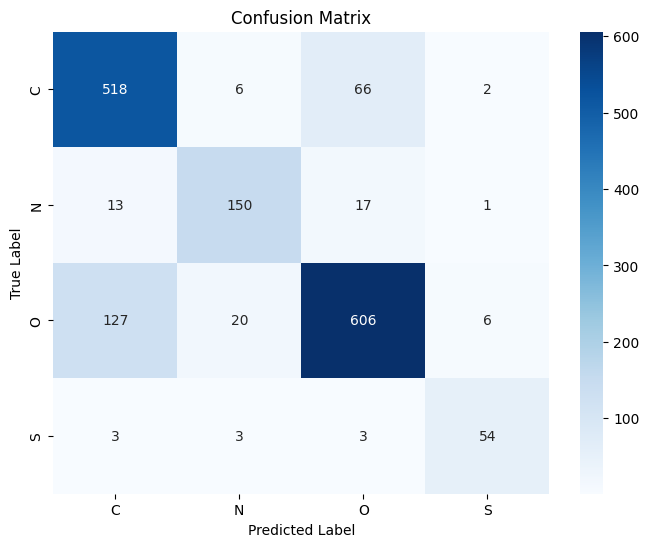

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get the class labels from the LabelEncoder
class_labels = le.inverse_transform(np.arange(len(le.classes_)))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [13]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=class_labels)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           C       0.78      0.88      0.83       592
           N       0.84      0.83      0.83       181
           O       0.88      0.80      0.84       759
           S       0.86      0.86      0.86        63

    accuracy                           0.83      1595
   macro avg       0.84      0.84      0.84      1595
weighted avg       0.84      0.83      0.83      1595



Imagine our model is trying to put different chemical molecules into one of four categories: 'C' (Carbon-only), 'N' (Nitrogen-containing), 'O' (Oxygen-containing), and 'S' (Sulfur-containing).

**Precision:**     
Think of this as, "When the model says a molecule belongs to a certain category, how often is it right?"

For 'O' molecules, our model has a precision of 0.88. This means when it predicts a molecule is 'O', it's correct 88% of the time. That's pretty good!
For 'C' molecules, the precision is 0.78. So, when it claims a molecule is 'C', it's right 78% of the time.  
**Recall:**  
This is about how many of the actual molecules in a category the model successfully found. Think of it as, "Out of all the molecules that really are 'O', how many did the model correctly identify as 'O'?"

For 'C' molecules, our model has a recall of 0.88. This means it correctly identified 88% of all the actual 'C' molecules in the test set.
For 'O' molecules, the recall is 0.80. It found 80% of all the actual 'O' molecules.  

**F1-Score:**   
This is a single score that tries to balance both Precision and Recall. It's a good overall measure of a model's accuracy, especially when some categories might be rarer than others. A higher F1-score means the model is doing a good job at both being precise and having good recall.

You can see the F1-scores are all quite good, ranging from 0.83 to 0.86.
Support: This simply tells you how many molecules of each category were in our test dataset. For example, there were 759 'O' molecules and 63 'S' molecules in the test set.

**Accuracy:**  
This is the most straightforward one, it's the total percentage of all molecules that the model classified correctly. Our model got 83% of all predictions right.

> In summary, this report shows that your Logistic Regression model is performing quite well! It's doing a solid job of identifying and classifying molecules into their correct categories, with a good balance between precision and recall across the different types.

## 9 Improve model

<h1>Address Class Imbalance</h1>

We noticed earlier that our categories ('C', 'N', 'O', 'S') are not evenly distributed. For example, there are many more 'O' and 'C' molecules than 'N' or 'S' molecules. This can sometimes make a model biased towards the more common categories.

**Approach:**
*   **Oversampling:** Make more copies of the molecules from the smaller categories (e.g., 'N' and 'S') so the model sees them more often during training.
*   **Undersampling:** Reduce the number of molecules from the larger categories (e.g., 'O' and 'C') to match the size of the smaller ones.

There are libraries like `imbalanced-learn` that make this easy, but for now, it's good to understand the concept.

<h1> Hyperparameter Tuning </h1>

Every machine learning model has settings that you can adjust. These settings are called **hyperparameters**. For our `LogisticRegression` model, examples include `solver` (how it solves the math problem) or `C` (a regularization parameter that controls how much the model avoids overfitting).

**Approach:**
*   We can try different combinations of these settings to see which ones give the best performance. Tools like `GridSearchCV` or `RandomizedSearchCV` can automate this process, trying out many different settings for us.

<h1> Feature Scaling </h1>

Our features (the `mz` values) are all positive integers, but some models can perform better if all features are on a similar scale (e.g., all values between 0 and 1, or with a mean of 0 and standard deviation of 1). This is called **feature scaling**.

**Approach:**
*   We can use techniques like **Standardization** (making the mean 0 and standard deviation 1) or **Normalization** (scaling values between 0 and 1). While Logistic Regression is less sensitive to scaling than some other models, it's generally a good practice for many algorithms.

Let's try implementing feature scaling as a simple improvement step to see its effect.

<h1> Try other model: for example XGBoost Classifier </h1>

**XGBoost** is a highly efficient and flexible implementation of the gradient boosting algorithm. It's often used for its speed, performance, and ability to handle various data types and complexities. It builds multiple decision trees sequentially, with each new tree trying to correct the errors of the previous ones.

In [14]:
# First, we need to install XGBoost
!pip install xgboost

import xgboost as xgb
from sklearn.metrics import accuracy_score

# Initialize the XGBoost Classifier
# Using 'objective' for multi-class classification and 'eval_metric' for evaluation
# 'use_label_encoder=False' and 'enable_categorical=True' are for more modern XGBoost versions
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # For multi-class classification
    num_class=len(le.classes_), # Number of target classes
    eval_metric='mlogloss',     # Metric for evaluation
    use_label_encoder=False,    # Suppress deprecation warning
    random_state=42             # For reproducibility
)

# Train the model using the original (non-scaled) training data
# XGBoost can handle raw feature values well, but scaling can sometimes help
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate the accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Test Set Accuracy with XGBoost Classifier: {accuracy_xgb:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:48:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Set Accuracy with XGBoost Classifier: 0.9354


XGBoost Model Evaluation (Confusion Matrix and Classification Report)

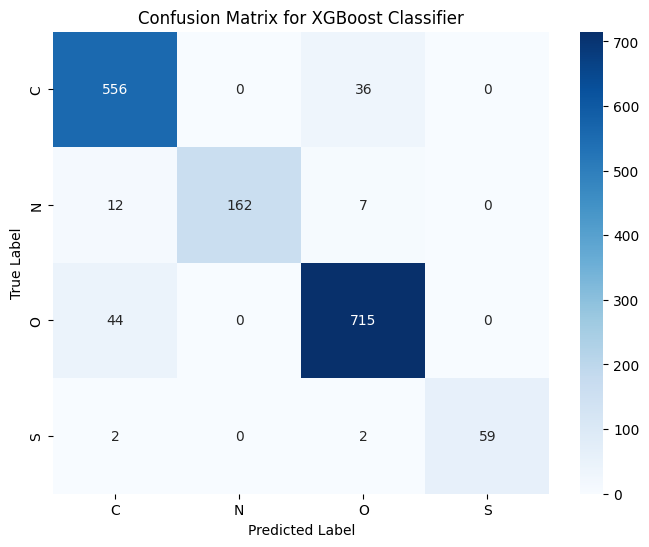


Classification Report for XGBoost Classifier:
              precision    recall  f1-score   support

           C       0.91      0.94      0.92       592
           N       1.00      0.90      0.94       181
           O       0.94      0.94      0.94       759
           S       1.00      0.94      0.97        63

    accuracy                           0.94      1595
   macro avg       0.96      0.93      0.94      1595
weighted avg       0.94      0.94      0.94      1595



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate the confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Get the class labels from the LabelEncoder
# Assuming 'le' and 'class_labels' are still available from previous execution
class_labels = le.inverse_transform(np.arange(len(le.classes_)))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate the classification report for XGBoost
report_xgb = classification_report(y_test, y_pred_xgb, target_names=class_labels)

print("\nClassification Report for XGBoost Classifier:")
print(report_xgb)

## 10 Save. load and use model

In [16]:
# save model
import pickle
with open('/content/drive/MyDrive/COAST COURSE/FINAL/xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

In [17]:
# load model
import pickle
with open('/content/drive/MyDrive/COAST COURSE/FINAL/xgb_model.pkl', 'rb') as file:
    loaded_xgb_model = pickle.load(file)

In [19]:
# use model to predict class from spectrum

# Select an index from the test set for demonstration
sample_index = 4

# Get the spectrum (features) for the selected sample
new_spectrum = X_test[sample_index]

# Reshape the spectrum to be a 2D array (1 sample, n_features) as expected by the model
new_spectrum_reshaped = new_spectrum.reshape(1, -1)

# Predict the category using the loaded model
predicted_category_encoded = loaded_xgb_model.predict(new_spectrum_reshaped)

# Convert the encoded prediction back to the original category name
predicted_category = le.inverse_transform(predicted_category_encoded)

# Get the actual category for comparison (from the test set)
actual_category_encoded = y_test[sample_index]
actual_category = le.inverse_transform([actual_category_encoded])

print(f"Predicted Category: {predicted_category[0]}")

Predicted Category: O
